In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pickle
import pandas as pd
import seaborn as sns
from tqdm import tqdm
from DN_tools import load_into_pandas
import os
from scipy.stats import pearsonr

plt.style.use("W:/apalaci/code/janache/DNpaper.mplstyle")

In [14]:
raw_data_dir_path = 'W:/apalaci/code/janache'
datefolder = f'{raw_data_dir_path}/res/2025_glms_saving_idxs'
df = load_into_pandas(dir_path=raw_data_dir_path)
df.loc[df.DN == 'imposter','DN'] = 'DopaMeander'
df = df[(df.to_ignore == False)&(df.DN == 'MDN')].reset_index(drop=True)
df['unique_id'] = ['fly' + str(a) + 'cell' + str(b) for a,b in zip(df['#Fly'],df['#Cell'])]
unique_IDS = df['unique_id'].unique().tolist()

In [18]:
analysis_df = df
# analysis_ynames = ['v_fwd','abs_v_fwd','pos_v_fwd','neg_v_fwd', 'v_ang','abs_v_ang','pos_v_ang','neg_v_ang']
isplit = 0

pos_pearsonr_score = {}
neg_pearsonr_score = {}
for index, row in tqdm(analysis_df.iterrows()):
    filename = row['filename']
    DN_side = row['side']
    DN = row['DN']
    csv_path = row['abs_file_path']
    for ivar, varname in enumerate(['v_ang','abs_v_ang']):
        res_file_path = f'{datefolder}/{filename}_{varname}_isplit{isplit}.pkl'
        if os.path.exists(res_file_path):
            with open(res_file_path, 'rb') as handle:
                temp = pickle.load(handle)
                y_test = temp["y_test"]
                y_pred_test_nl = temp["y_pred_test_nl"]
                idx_test = temp["idx_test"]
                raw_v_fwd = temp["y_m"][idx_test,0]

                pos_pearsonr_score.update({f'{filename}||{varname}': pearsonr(y_pred_test_nl[raw_v_fwd > 0], y_test[raw_v_fwd > 0]).statistic})
                neg_pearsonr_score.update({f'{filename}||{varname}': pearsonr(y_pred_test_nl[raw_v_fwd < 0], y_test[raw_v_fwd < 0]).statistic})

0it [00:00, ?it/s]C:\Users\apalaci\AppData\Local\Temp\ipykernel_14296\3751233316.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pos_pearsonr_score.update({f'{filename}||{varname}': pearsonr(y_pred_test_nl[raw_v_fwd > 0], y_test[raw_v_fwd > 0]).statistic})
C:\Users\apalaci\AppData\Local\Temp\ipykernel_14296\3751233316.py:23: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  neg_pearsonr_score.update({f'{filename}||{varname}': pearsonr(y_pred_test_nl[raw_v_fwd < 0], y_test[raw_v_fwd < 0]).statistic})
23it [00:06,  3.45it/s]


In [19]:
data_df = pd.concat([
    pd.DataFrame(
        [(k.split("||")[0], k.split("||")[1], v, "pos")
         for k, v in pos_pearsonr_score.items()],
        columns=["filename", "varname", "value", "type"]
    ),
    pd.DataFrame(
        [(k.split("||")[0], k.split("||")[1], v, "neg")
         for k, v in neg_pearsonr_score.items()],
        columns=["filename", "varname", "value", "type"]
    )
], ignore_index=True)

data_df

,filename,varname,value,type
0,2022_08_18_0000,v_ang,NaN,pos
1,2022_08_18_0000,abs_v_ang,0.268885,pos
2,2022_09_12_0000,v_ang,0.205879,pos
3,2022_09_12_0000,abs_v_ang,0.357010,pos
4,2022_11_25_0009,v_ang,0.018246,pos
...,...,...,...,...
87,2023_08_11_0009,abs_v_ang,0.221893,neg
88,2023_08_11_0010,v_ang,0.234775,neg
89,2023_08_11_0010,abs_v_ang,0.471382,neg
90,2023_08_15_0000,v_ang,NaN,neg


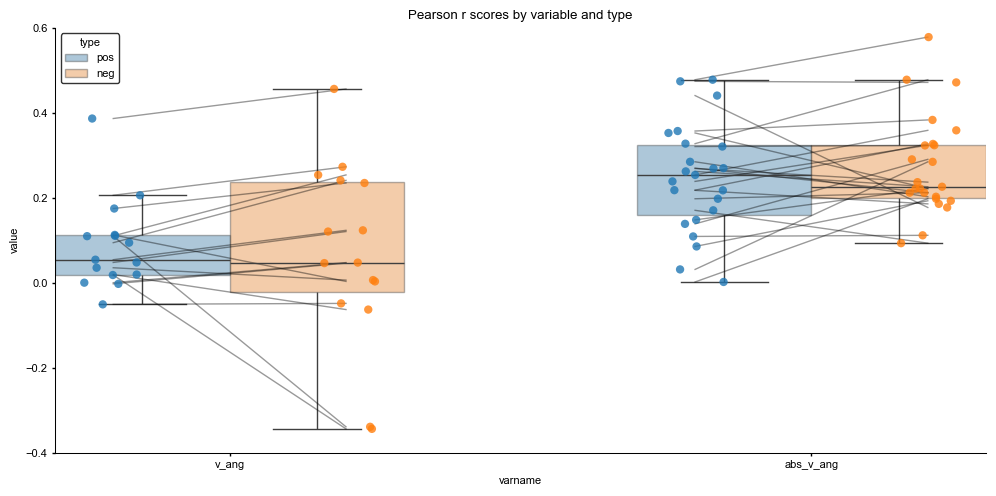

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, ax = plt.subplots(figsize=(10, 5))

# --- boxplot ---
sns.boxplot(
    data=data_df,
    x="varname",
    y="value",
    hue="type",
    dodge=True,
    width=0.6,
    showcaps=True,
    boxprops={"alpha": 0.4},
    fliersize=0,
    ax=ax,
)

# --- stripplot ---
sns.stripplot(
    data=data_df,
    x="varname",
    y="value",
    hue="type",
    dodge=True,
    jitter=True,
    alpha=0.8,
    size=6,
    ax=ax,
)

# --- remove duplicate legend entries ---
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], labels[:2], title="type")

# --- connect same filename across types ---
type_order = ["pos", "neg"]
x_offsets = {"pos": -0.2, "neg": 0.2}

varnames = data_df["varname"].unique()
x_base = {v: i for i, v in enumerate(varnames)}

for (fname, vname), g in data_df.groupby(["filename", "varname"]):
    if len(g) < 2:
        continue

    xs = [
        x_base[vname] + x_offsets[row["type"]]
        for _, row in g.iterrows()
    ]
    ys = g["value"].values

    ax.plot(xs, ys, color="k", alpha=0.4, linewidth=1)

ax.set_xlabel("varname")
ax.set_ylabel("value")
ax.set_title("Pearson r scores by variable and type")

plt.tight_layout()
plt.show()


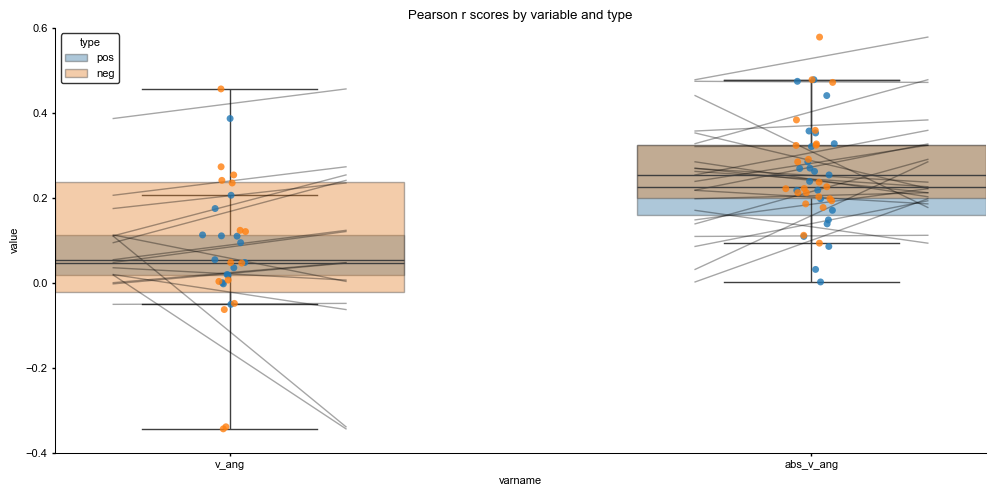

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

type_order = ["pos", "neg"]
x_offsets = {"pos": -0.2, "neg": 0.2}

# --- boxplot ---
sns.boxplot(
    data=data_df,
    x="varname",
    y="value",
    hue="type",
    hue_order=type_order,
    dodge=True,
    width=0.6,
    showcaps=True,
    boxprops={"alpha": 0.4},
    fliersize=0,
    ax=ax,
)

# --- stripplot (NO jitter, perfectly centered) ---
sns.stripplot(
    data=data_df,
    x="varname",
    y="value",
    hue="type",
    hue_order=type_order,
    dodge=True,
    jitter=False,   # <- critical
    alpha=0.8,
    size=5,
    ax=ax,
)

# --- manually add very small jitter in x (optional) ---
rng = np.random.default_rng(0)
for coll in ax.collections:
    offsets = coll.get_offsets()
    if offsets.size == 0:
        continue
    offsets[:, 0] += rng.normal(scale=0.02, size=len(offsets))
    coll.set_offsets(offsets)

# --- clean legend (avoid duplicates) ---
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], labels[:2], title="type")

# --- connect same filename across types ---
varnames = data_df["varname"].unique()
x_base = {v: i for i, v in enumerate(varnames)}

for (fname, vname), g in data_df.groupby(["filename", "varname"]):
    if len(g) < 2:
        continue

    xs = [
        x_base[vname] + x_offsets[row["type"]]
        for _, row in g.iterrows()
    ]
    ys = g["value"].values

    ax.plot(xs, ys, color="k", alpha=0.35, linewidth=1)

ax.set_xlabel("varname")
ax.set_ylabel("value")
ax.set_title("Pearson r scores by variable and type")

plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import shapiro, ttest_rel, wilcoxon

def compare_pair(x, y, verbose=False):
    assert len(x) == len(y), "Paired arrays must have same length"

    if (shapiro(x).pvalue < 0.05) or (shapiro(y).pvalue < 0.05):
        if verbose:
            print('using wilcoxon')
        p = wilcoxon(x, y, alternative='two-sided', nan_policy='omit').pvalue
    else:
        if verbose:
            print(f'using ttest_rel {np.sum(~(np.isnan(x) | np.isnan(y)))} from {len(x)}')
        p = ttest_rel(x, y, nan_policy='omit').pvalue

    return p

def get_paired_data(df, idx1, idx2, unit_id_col='filename', value_col='pearsonr_score'):
    a = df.loc[idx1, [unit_id_col, value_col]]
    b = df.loc[idx2, [unit_id_col, value_col]]

    paired = (
        a.merge(b, on=unit_id_col, suffixes=('_a', '_b'))
        .dropna()
    )

    return paired[f'{value_col}_a'].to_numpy(), paired[f'{value_col}_b'].to_numpy()

C:\Users\apalaci\AppData\Local\Temp\ipykernel_14296\2516524958.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['raw','abs.'])


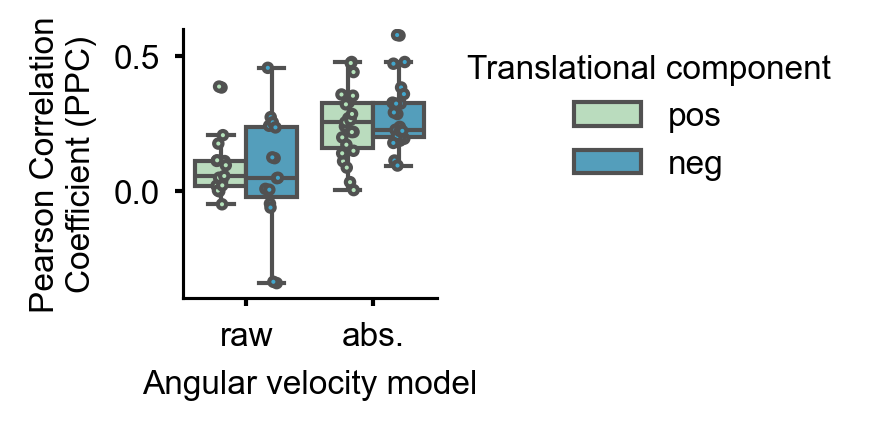

In [ ]:
cm = 1/2.54
figsize_unit = 3*cm

plt.figure(figsize = [2.5*figsize_unit,1.25*figsize_unit],dpi=300,layout='tight')

ax =plt.gca()
sns.boxplot(x="varname", y="value", hue="type", data=data_df, palette="GnBu",ax=ax,fliersize=2)
sns.stripplot(x="varname", y="value", hue="type", data=data_df, palette="GnBu", dodge=True, ax=ax, linewidth=1,size=2)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], labels[:2], title='Translational component', bbox_to_anchor=(1, 1.02), loc='upper left', frameon=False)



ax.set_ylabel('Pearson Correlation\nCoefficient (PPC)')
ax.set_xlabel('Angular velocity model')
ax.set_xticklabels(['raw','abs.'])
plt.savefig(f'../fig/rebuttal/ang_models_by_fwd_sign.png', transparent=False, bbox_inches='tight', dpi=300)
plt.show()

In [ ]:
# unit_id_col should be created with filename and varname, to uniquely identify each row in the dataframe before pairing
df_sorted = (
    data_df
    .sort_values(["varname", "filename"])
    .reset_index(drop=True)
)
df_sorted

,filename,varname,value,type
0,2022_08_18_0000,abs_v_ang,0.268885,pos
1,2022_08_18_0000,abs_v_ang,0.236724,neg
2,2022_09_12_0000,abs_v_ang,0.357010,pos
3,2022_09_12_0000,abs_v_ang,0.383120,neg
4,2022_11_25_0009,abs_v_ang,0.238519,pos
...,...,...,...,...
87,2023_08_11_0009,v_ang,NaN,neg
88,2023_08_11_0010,v_ang,0.174692,pos
89,2023_08_11_0010,v_ang,0.234775,neg
90,2023_08_15_0000,v_ang,NaN,pos


In [50]:
for varname, g in df_sorted.groupby("varname"):
    wide = (
        g
        .pivot(index="filename", columns="type", values="value")
        .dropna(subset=["pos", "neg"])
    )

    pos_vals = wide["pos"].values
    neg_vals = wide["neg"].values

    stat, pval = ttest_rel(pos_vals, neg_vals)
    
    print(varname, stat, pval, pval*4)

for varname, g in df_sorted.groupby("type"):
    wide = (
        g
        .pivot(index="filename", columns="varname", values="value")
        .dropna(subset=["v_ang", "abs_v_ang"])
    )

    A = wide["v_ang"].values
    B = wide["abs_v_ang"].values

    stat, pval = ttest_rel(A, B)
    
    print(varname, stat, pval, pval*4)

abs_v_ang -1.1982072913761304 0.24358564871547936 0.9743425948619174
v_ang 0.4563562909991146 0.6551332327984134 2.6205329311936536
neg -3.619395306095437 0.0027890762852981438 0.011156305141192575
pos -5.737936969350107 5.1317743500637654e-05 0.00020527097400255062
